In [19]:
from pathlib import Path
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
from stable_platform_matchings.domain.instance import Instance
import seaborn as sns

In [63]:
sns.set_theme(context="paper", style="ticks")

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

def currency_formatter(x, pos):
    return f"${x:.0f}"

def pp_formatter(x, pos):
    return f"{x * 100:.0f}pp"

In [64]:
root = Path("../results/exp_2")
jsons = list(root.rglob("*.json.gz"))

graph_data_filename = "../data/graph_0-14960_00_new.pickle"
instance = Instance.from_yaml(Path("../data/anon_14_day_instances/2020-08-27.yaml"))

In [65]:
actual_costs_platform = {
    0: 0.0775829869015126,
    1: 0.07768902868743288,
    2: 0.07792714074761442,
    3: 0.07779050019770295,
    4: 0.07780432119364723,
    5: 0.07780432119364725,
    6: 0.07758298690151258,
    7: 0.07758298690151257,
    8: 0.07758298690151258,
    9: 0.0775829869015126,
 }

actual_costs_improvement = {
    i: actual_costs_platform[i] - actual_costs_platform[0] 
    for i in range(1, 10)
}

actual_perc_platform = {
    0: 0.09959740695143612,
    1: 0.044517655245960054,
    2: 0.022845478696154217,
    3: 0.011845342163052535,
    4: 0.005042216382378989,
    5: 0.0009595428605521555,
    6: -0.002270061056467741,
    7: -0.004516052387438745,
    8: -0.005835568402234102,
    9: -0.007022154488203626
 }

actual_max_int = {
    0: 0.32758953661755996,
    1: 0.04175691614041955,
    2: 0.02060091126517644,
    3: 0.013039289559810586,
    4: 0.009350912870058112,
    5: 0.007924168304404811,
    6: 0.00772484422378011,
    7: 0.007443614889069343,
    8: 0.0063391957909994575,
    9: 0.005711990106601736
 }

actual_min_int = {
    0: 0.0,
    1: 0.01478574070810623,
    2: 0.007534357335050608,
    3: 0.007899933576455203,
    4: 0.005905858766726449,
    5: 0.006235383720283765,
    6: 0.0058198497457951585,
    7: 0.0073826381391337735,
    8: 0.006322061118747919,
    9: 0.00571137535532129
 }

actual_min_farmer = {
    0: 0.4952300812484759,
    1: 0.8360364116451723,
    2: 0.8786264810100395,
    3: 0.8973248797984186,
    4: 0.9078025612729003,
    5: 0.9133119793603803,
    6: 0.9169622416501595,
    7: 0.9194894623158415,
    8: 0.9219133974287067,
    9: 0.9237271891990739
 }

actual_max_farmer = {
    0: 0.8228196178660359,
    1: 0.8630075870774853,
    2: 0.8916930349401653,
    3: 0.9024642357817737,
    4: 0.911247615376232,
    5: 0.9150007639445015,
    6: 0.9188672361281446,
    7: 0.9195504390657769,
    8: 0.9219305321009583,
    9: 0.9237278039503545
 }


In [66]:
# load data
data = []
for file in jsons:
    with gzip.open(file, "rt", encoding="utf-8") as f:
        aggregate_payload = json.load(f)

    for payload in aggregate_payload["runs"]:
        vanilla_no_pay = payload["summary_vanilla_no_pay"]
        structured_no_pay = payload["summary_structured_no_pay"]
        dominance_no_pay = payload["summary_dominance_no_pay"]

        vanilla_pay = payload["summary_vanilla_pay"]
        structured_pay = payload["summary_structured_pay"]
        dominance_pay = payload["summary_dominance_pay"]


        epsilon = np.mean(list(payload["sampled_inputs"]["epsilons"].values()))
        fruit_value = (
            np.sum(
                list(payload["sampled_inputs"]["quantities"].values())
            ) * instance.fruit_price_per_ton
        )

        vanilla_profit_pct_no_pay = (
            vanilla_no_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["platform_profit"]
            / fruit_value
        )
        vanilla_profit_pct_pay = (
            vanilla_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["platform_profit"] 
            / fruit_value
        )
        structured_profit_pct_no_pay = (
            structured_no_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["platform_profit"] 
            / fruit_value
        )
        structured_profit_pct_pay = (
            structured_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["platform_profit"] 
            / fruit_value
        )
        dominance_profit_pct_no_pay = (
            dominance_no_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["platform_profit"] 
            / fruit_value
        )
        dominance_profit_pct_pay = (
            dominance_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["platform_profit"] 
            / fruit_value
        )

        max_farmer_welfare_pct_no_pay = (
            vanilla_no_pay["platform_solve_result"]
            ["max_farmer_welfare_result"]
            ["farmer_welfare"] 
            / fruit_value
        )
        min_farmer_welfare_pct_no_pay = (
            vanilla_no_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["farmer_welfare"] 
            / fruit_value
        )
        max_intermediary_welfare_pct_no_pay = (
            vanilla_no_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["intermediary_welfare"] 
            / fruit_value
        )
        min_intermediary_welfare_pct_no_pay = (
            vanilla_no_pay["platform_solve_result"]
            ["max_farmer_welfare_result"]
            ["intermediary_welfare"] 
            / fruit_value
        )

        max_farmer_welfare_pct_pay = (
            vanilla_pay["platform_solve_result"]
            ["max_farmer_welfare_result"]
            ["farmer_welfare"] 
            / fruit_value
        )
        min_farmer_welfare_pct_pay = (
            vanilla_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["farmer_welfare"] 
            / fruit_value
        )
        max_intermediary_welfare_pct_pay = (
            vanilla_pay["platform_solve_result"]
            ["max_intermediary_welfare_result"]
            ["intermediary_welfare"] 
            / fruit_value
        )
        min_intermediary_welfare_pct_pay = (
            vanilla_pay["platform_solve_result"]
            ["max_farmer_welfare_result"]
            ["intermediary_welfare"] 
            / fruit_value
        )

        data.append({
            "epsilon": epsilon,
            "vanilla_profit_pct_no_pay": vanilla_profit_pct_no_pay,
            "vanilla_profit_pct_pay": vanilla_profit_pct_pay,
            
            "structured_profit_pct_no_pay": structured_profit_pct_no_pay,
            "structured_profit_pct_pay": structured_profit_pct_pay,
            "structured_profit_pct_diff": structured_profit_pct_pay - structured_profit_pct_no_pay,

            "dominance_profit_pct_no_pay": dominance_profit_pct_no_pay,
            "dominance_profit_pct_pay": dominance_profit_pct_pay,
            

            "max_intermediary_welfare_pct_no_pay": max_intermediary_welfare_pct_no_pay,
            "max_intermediary_welfare_pct_pay": max_intermediary_welfare_pct_pay,
            
            "min_intermediary_welfare_pct_no_pay": min_intermediary_welfare_pct_no_pay,
            "min_intermediary_welfare_pct_pay": min_intermediary_welfare_pct_pay,

            "max_farmer_welfare_pct_no_pay": max_farmer_welfare_pct_no_pay,
            "max_farmer_welfare_pct_pay": max_farmer_welfare_pct_pay,
            
            "min_farmer_welfare_pct_no_pay": min_farmer_welfare_pct_no_pay,
            "min_farmer_welfare_pct_pay": min_farmer_welfare_pct_pay,
        })  

df = pd.DataFrame(data).query("epsilon >= 1")


In [67]:
df["vanilla_profit_pct_diff"] = df["vanilla_profit_pct_pay"] - df["vanilla_profit_pct_no_pay"]
df["dominance_profit_pct_diff"] = df["dominance_profit_pct_pay"] - df["dominance_profit_pct_no_pay"]
df["max_intermediary_welfare_pct_diff"] = (
    df["max_intermediary_welfare_pct_pay"] - df["max_intermediary_welfare_pct_no_pay"]
)
df["min_intermediary_welfare_pct_diff"] = (
    df["min_intermediary_welfare_pct_pay"] - df["min_intermediary_welfare_pct_no_pay"]
)
df["max_farmer_welfare_pct_diff"] = (
    df["max_farmer_welfare_pct_pay"] - df["max_farmer_welfare_pct_no_pay"]
)
df["min_farmer_welfare_pct_diff"] = (
    df["min_farmer_welfare_pct_pay"] - df["min_farmer_welfare_pct_no_pay"]
)

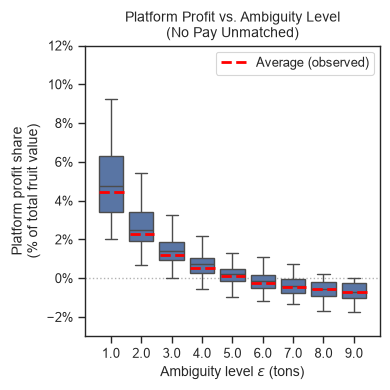

In [68]:
plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df, 
    x="epsilon", 
    y="vanilla_profit_pct_no_pay", 
    zorder=1, 
    showfliers=False,
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)


for i, category in enumerate(list(range(1, 10))):
    obs = actual_perc_platform.get(category, None)
    if obs is not None:
        plt.plot(
            [i - 0.38, i + 0.42], 
            [obs, obs], 
            color="red", 
            linewidth=2, 
            linestyle="--",  # Dashed line for the average
            label="Average (observed)" if i == 0 else "", 
            zorder=10
        )


ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylabel("Platform profit share\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level\n(No Pay Unmatched)")

plt.legend()
plt.ylim(-0.03, 0.12)
plt.tight_layout()
plt.savefig("../figures/exp_2/platform_profit_no_pay.png", bbox_inches="tight", dpi=300)
plt.show()

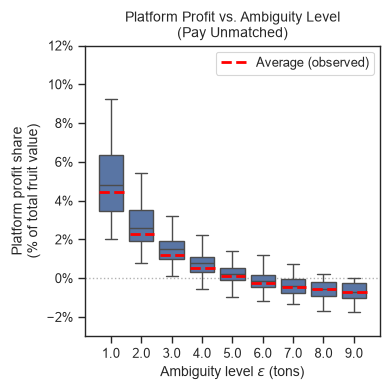

In [69]:
plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df, 
    x="epsilon", 
    y="vanilla_profit_pct_pay", 
    zorder=1, 
    showfliers=False,
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)


for i, category in enumerate(list(range(1, 10))):
    obs = actual_perc_platform.get(category, None)
    if obs is not None:
        plt.plot(
            [i - 0.38, i + 0.42], 
            [obs, obs], 
            color="red", 
            linewidth=2, 
            linestyle="--",  # Dashed line for the average
            label="Average (observed)" if i == 0 else "", 
            zorder=10
        )


ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylabel("Platform profit share\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level\n(Pay Unmatched)")

plt.legend()
plt.ylim(-0.03, 0.12)
plt.tight_layout()
plt.savefig("../figures/exp_2/platform_profit_pay.png", bbox_inches="tight", dpi=300)
plt.show()

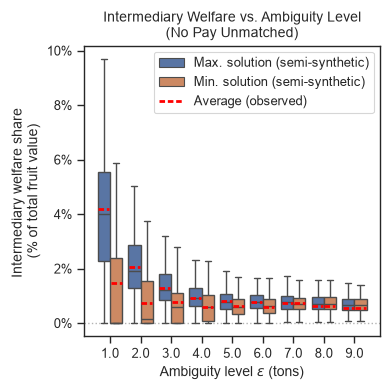

In [70]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["max_intermediary_welfare_pct_no_pay", "min_intermediary_welfare_pct_no_pay"], 
    var_name="Welfare Type", 
    value_name="Welfare"
)

df_melted["Welfare Type"] = df_melted["Welfare Type"].map({
    "max_intermediary_welfare_pct_no_pay": "Max. solution (semi-synthetic)", 
    "min_intermediary_welfare_pct_no_pay": "Min. solution (semi-synthetic)"
})


plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

for i, category in enumerate(sorted(df["epsilon"].unique())):
    obs_max = actual_max_int.get(category, None)
    obs_min = actual_min_int.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylabel("Intermediary welfare share \n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare vs. Ambiguity Level\n(No Pay Unmatched)")

plt.legend()
plt.tight_layout()
plt.savefig("../figures/exp_2/intermediary_welfare_no_pay.png", bbox_inches="tight", dpi=300)
plt.show()

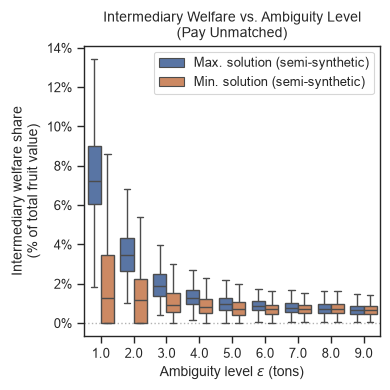

In [71]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["max_intermediary_welfare_pct_pay", "min_intermediary_welfare_pct_pay"], 
    var_name="Welfare Type", 
    value_name="Welfare"
)

df_melted["Welfare Type"] = df_melted["Welfare Type"].map({
    "max_intermediary_welfare_pct_pay": "Max. solution (semi-synthetic)", 
    "min_intermediary_welfare_pct_pay": "Min. solution (semi-synthetic)"
})


plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylabel("Intermediary welfare share\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare vs. Ambiguity Level\n(Pay Unmatched)")

plt.legend()
plt.tight_layout()
plt.savefig("../figures/exp_2/intermediary_welfare_pay.png", bbox_inches="tight", dpi=300)
plt.show()

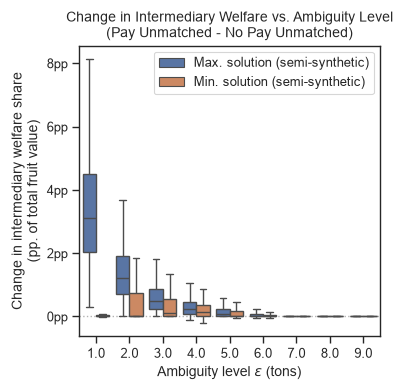

In [73]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["max_intermediary_welfare_pct_diff", "min_intermediary_welfare_pct_diff"], 
    var_name="Welfare Type", 
    value_name="Welfare"
)

df_melted["Welfare Type"] = df_melted["Welfare Type"].map({
    "max_intermediary_welfare_pct_diff": "Max. solution (semi-synthetic)", 
    "min_intermediary_welfare_pct_diff": "Min. solution (semi-synthetic)"
})

plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

ax.yaxis.set_major_formatter(pp_formatter)

plt.ylabel("Change in intermediary welfare share\n(pp. of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Change in Intermediary Welfare vs. Ambiguity Level\n(Pay Unmatched - No Pay Unmatched)")

plt.legend()
plt.tight_layout()
plt.savefig("../figures/exp_2/intermediary_welfare_diff.png", bbox_inches="tight", dpi=300)
plt.show()

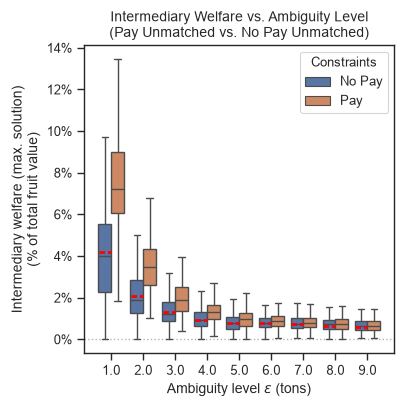

In [74]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["max_intermediary_welfare_pct_no_pay", "max_intermediary_welfare_pct_pay"], 
    var_name="Constraints", 
    value_name="Welfare"
)

df_melted["Constraints"] = df_melted["Constraints"].map({
    "max_intermediary_welfare_pct_no_pay": "No Pay", 
    "max_intermediary_welfare_pct_pay": "Pay"
})

plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Constraints", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

for i, category in enumerate(sorted(df_melted["epsilon"].unique())):
    obs_max = actual_max_int.get(category, None)
    obs_min = actual_min_int.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])


ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylabel("Intermediary welfare (max. solution)\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Intermediary Welfare vs. Ambiguity Level\n(Pay Unmatched vs. No Pay Unmatched)")
plt.savefig("../figures/exp_2/max_intermediary_welfare_diff.png", bbox_inches="tight", dpi=300)
plt.show()

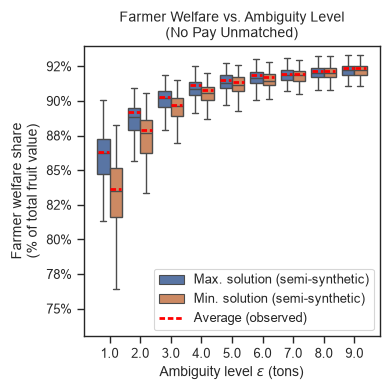

In [75]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["max_farmer_welfare_pct_no_pay", "min_farmer_welfare_pct_no_pay"], 
    var_name="Welfare Type", 
    value_name="Welfare"
)

df_melted["Welfare Type"] = df_melted["Welfare Type"].map({
    "max_farmer_welfare_pct_no_pay": "Max. solution (semi-synthetic)", 
    "min_farmer_welfare_pct_no_pay": "Min. solution (semi-synthetic)"
})

plt.figure(figsize=(4, 4))  

ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette="deep",
    showfliers=False
)

for i, category in enumerate(sorted(df["epsilon"].unique())):
    obs_max = actual_max_farmer.get(category, None)
    obs_min = actual_min_farmer.get(category, None)
    if obs_max is not None:
        line, = plt.plot(
            [i - 0.38, i - 0.02], [obs_max, obs_max], 
            color="red", linewidth=2, linestyle="--", 
            label="Average (observed)" if i == 0 else "", zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap
    if obs_min is not None:
        line, = plt.plot(
            [i + 0.02, i + 0.38], [obs_min, obs_min], 
            color="red", linewidth=2, linestyle="--", 
            label=None, zorder=10
        )
        line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylabel("Farmer welfare share\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare vs. Ambiguity Level\n(No Pay Unmatched)")

plt.legend()
plt.ylim(0.73, 0.94)
plt.tight_layout()
plt.savefig("../figures/exp_2/farmer_welfare_no_pay.png", bbox_inches="tight", dpi=300)
plt.show()

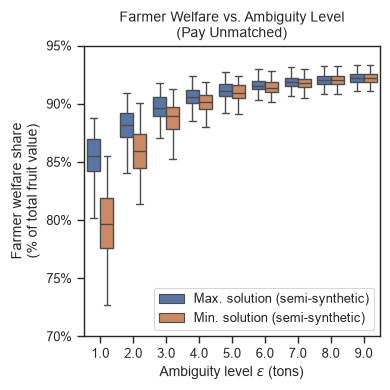

In [76]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["max_farmer_welfare_pct_pay", "min_farmer_welfare_pct_pay"], 
    var_name="Welfare Type", 
    value_name="Welfare"
)

df_melted["Welfare Type"] = df_melted["Welfare Type"].map({
    "max_farmer_welfare_pct_pay": "Max. solution (semi-synthetic)", 
    "min_farmer_welfare_pct_pay": "Min. solution (semi-synthetic)"
})

plt.figure(figsize=(4, 4)) 

ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette="deep",
    showfliers=False
)

ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylabel("Farmer welfare share\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare vs. Ambiguity Level\n(Pay Unmatched)")

plt.legend()
plt.ylim(0.7, 0.95)
plt.tight_layout()
plt.savefig("../figures/exp_2/farmer_welfare_pay.png", bbox_inches="tight", dpi=300)
plt.show()

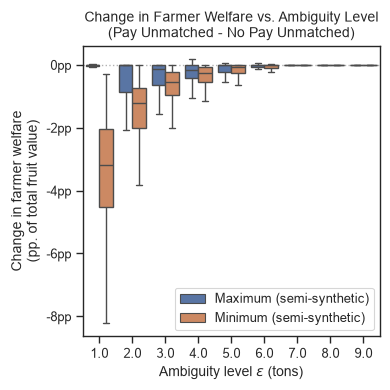

In [77]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["max_farmer_welfare_pct_diff", "min_farmer_welfare_pct_diff"], 
    var_name="Welfare Type", 
    value_name="Welfare"
)

df_melted["Welfare Type"] = df_melted["Welfare Type"].map({
    "max_farmer_welfare_pct_diff": "Maximum (semi-synthetic)", 
    "min_farmer_welfare_pct_diff": "Minimum (semi-synthetic)"
})

plt.figure(figsize=(4, 4))  

ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Welfare Type", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

ax.yaxis.set_major_formatter(FuncFormatter(pp_formatter))

plt.ylabel("Change in farmer welfare\n(pp. of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Change in Farmer Welfare vs. Ambiguity Level\n(Pay Unmatched - No Pay Unmatched)")

plt.legend()
plt.tight_layout()
plt.savefig("../figures/exp_2/farmer_welfare_diff.png", bbox_inches="tight", dpi=300)
plt.show()

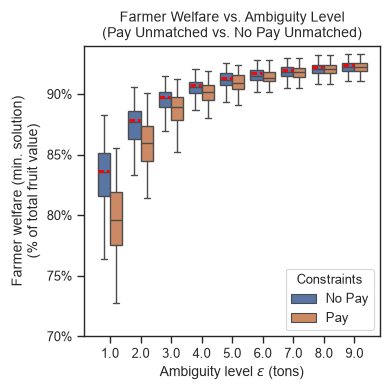

In [78]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["min_farmer_welfare_pct_no_pay", "min_farmer_welfare_pct_pay"], 
    var_name="Constraints", 
    value_name="Welfare"
)

df_melted["Constraints"] = df_melted["Constraints"].map({
    "min_farmer_welfare_pct_no_pay": "No Pay", 
    "min_farmer_welfare_pct_pay": "Pay"
})


plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Constraints", 
    palette="deep",
    showfliers=False
)

for i, category in enumerate(sorted(df_melted["epsilon"].unique())):
    obs_max = actual_max_farmer.get(category, None)
    obs_min = actual_min_farmer.get(category, None)
    if obs_min is not None:
            line, = plt.plot(
                [i - 0.38, i - 0.02], [obs_min, obs_min], 
                color="red", linewidth=2, linestyle="--", 
                label=None, zorder=10
            )
            line.set_dashes([2, 1])  # Custom dash pattern: short dash, small gap
            
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylabel("Farmer welfare (min. solution)\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Farmer Welfare vs. Ambiguity Level\n(Pay Unmatched vs. No Pay Unmatched)")

plt.ylim(0.7, 0.94)
plt.tight_layout()
plt.savefig("../figures/exp_2/min_farmer_welfare_diff.png", bbox_inches="tight", dpi=300)
plt.show()

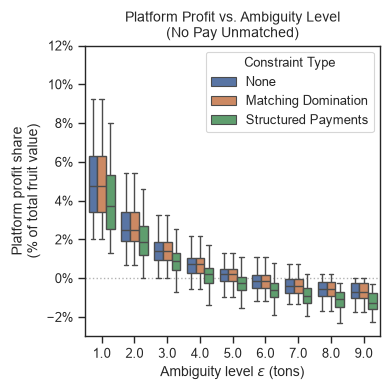

In [79]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["vanilla_profit_pct_no_pay", "dominance_profit_pct_no_pay", "structured_profit_pct_no_pay"], 
    var_name="Constraints", 
    value_name="Profit"
)

df_melted["Constraints"] = df_melted["Constraints"].map({
    "vanilla_profit_pct_no_pay": "None", 
    "dominance_profit_pct_no_pay": "Matching Domination", 
    "structured_profit_pct_no_pay": "Structured Payments"
})

plt.figure(figsize=(4, 4))
ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Profit", 
    hue="Constraints", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.ylabel("Platform profit share\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level\n(No Pay Unmatched)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylim(-0.03, 0.12)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Constraint Type", loc="upper right")

plt.tight_layout()
plt.savefig("../figures/exp_2/profit_by_constraint_no_pay.png", bbox_inches="tight", dpi=300)
plt.show()

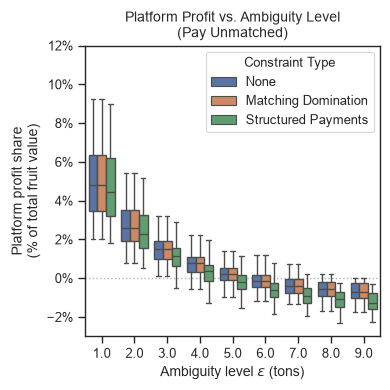

In [80]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["vanilla_profit_pct_pay", "dominance_profit_pct_pay", "structured_profit_pct_pay"], 
    var_name="Constraints", 
    value_name="Profit"
)

df_melted["Constraints"] = df_melted["Constraints"].map({
    "vanilla_profit_pct_pay": "None", 
    "dominance_profit_pct_pay": "Matching Domination", 
    "structured_profit_pct_pay": "Structured Payments"
})

plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Profit", 
    hue="Constraints", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.ylabel("Platform profit share\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level\n(Pay Unmatched)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

plt.ylim(-0.03, 0.12)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Constraint Type", loc="upper right")

plt.tight_layout()
plt.savefig("../figures/exp_2/profit_by_constraint_pay.png", bbox_inches="tight", dpi=300)
plt.show()

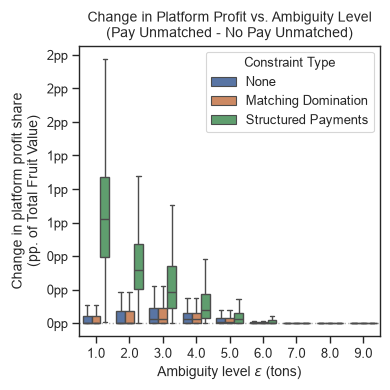

In [81]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["vanilla_profit_pct_diff", "dominance_profit_pct_diff", "structured_profit_pct_diff"], 
    var_name="Constraints", 
    value_name="Profit"
)

df_melted["Constraints"] = df_melted["Constraints"].map({
    "vanilla_profit_pct_diff": "None", 
    "dominance_profit_pct_diff": "Matching Domination", 
    "structured_profit_pct_diff": "Structured Payments"
})

plt.figure(figsize=(4, 4))

ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Profit", 
    hue="Constraints", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)

plt.ylabel("Change in platform profit share\n(pp. of Total Fruit Value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Change in Platform Profit vs. Ambiguity Level\n(Pay Unmatched - No Pay Unmatched)")
ax.yaxis.set_major_formatter(FuncFormatter(pp_formatter))

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Constraint Type", loc="upper right")

plt.tight_layout()
plt.savefig("../figures/exp_2/profit_by_constraint_diff.png", bbox_inches="tight", dpi=300)
plt.show()

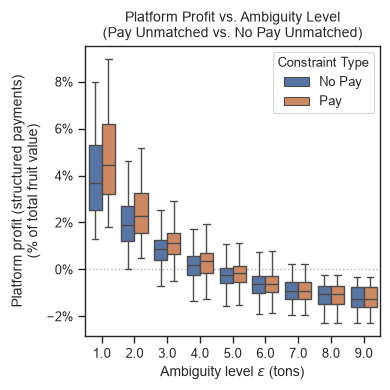

In [82]:
df_melted = df.melt(
    id_vars="epsilon", 
    value_vars=["structured_profit_pct_no_pay", "structured_profit_pct_pay"], 
    var_name="Constraints", 
    value_name="Welfare"
)

df_melted["Constraints"] = df_melted["Constraints"].map({
    "structured_profit_pct_no_pay": "No Pay", 
    "structured_profit_pct_pay": "Pay"
})

plt.figure(figsize=(4, 4))  

ax = sns.boxplot(
    data=df_melted, 
    x="epsilon", 
    y="Welfare", 
    hue="Constraints", 
    palette="deep",
    showfliers=False
)

plt.axhline(0, color="black", linestyle="dotted", linewidth=1, alpha=0.3, zorder=0)
            
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
plt.ylabel("Platform profit (structured payments)\n(% of total fruit value)")
plt.xlabel(r"Ambiguity level $\epsilon$ (tons)")
plt.title("Platform Profit vs. Ambiguity Level\n(Pay Unmatched vs. No Pay Unmatched)")

plt.legend(title="Constraint Type")

plt.tight_layout()
plt.savefig("../figures/exp_2/structured_platform_profit_diff.png", bbox_inches="tight", dpi=300)
plt.show()